# **TRANSFERÊNCIA DE ESTILO NEURAL**

Introduzido por Leon Gatys et al. Em 2015, em seu artigo intitulado “Um algoritmo neural para estilo artístico (https://arxiv.org/abs/1508.06576)”, o algoritmo de transferência de estilo neural se tornou viral, resultando em uma explosão de novos aplicativos de trabalho e móveis.

![](https://github.com/rajeevratan84/ModernComputerVision/raw/main/NST.png)

O Neural Style Transfer (NST) é uma técnica de inteligência artificial que combina o conteúdo de uma imagem com o estilo artístico de outra, criando uma nova imagem sintetizada. Desenvolvida inicialmente em 2015 por Gatys et al., a técnica utiliza redes neurais convolucionais (CNNs) para extrair características visuais de duas imagens distintas e fundi-las de forma harmoniosa. Recursos Computacionais: O método original de Gatys é lento (minutos/horas por imagem).

A técnica se baseia em redes neurais pré-treinadas para reconhecimento de objetos (ex: VGG19). A ideia central é que camadas diferentes da rede capturam informações diferentes:

- Camadas inferiores: Detectam bordas, cores e texturas simples (úteis para estilo).

- Camadas superiores: Capturam características complexas, como objetos ou estruturas (úteis para conteúdo).

1. Definição das Imagens:

    - Imagem de Conteúdo (C): A imagem que fornece a estrutura (ex: uma foto).

    - Imagem de Estilo (S): A imagem que fornece o estilo artístico (ex: uma pintura).

    - Imagem Gerada (G): A imagem inicial (geralmente ruído ou cópia de C) que será otimizada.

2. Extração de Características:

    - A rede neural processa as três imagens (C, S, G) e extrai ativações de camadas específicas
    
    - Camadas de Conteúdo: Normalmente camadas intermediárias (ex: conv4_2 no VGG19)

    - Camadas de Estilo: Múltiplas camadas (ex: conv1_1, conv2_1, conv3_1, etc.) para capturar texturas em diferentes escalas.

3. Cálculo das Funções de Perda:

    - Perda de Conteúdo (Content Loss): Mede a diferença entre as ativações da imagem gerada (G) e da imagem de conteúdo (C) nas camadas de     conteúdo.

    - Perda de Estilo (Style Loss): Usa a matriz de Gram (que captura correlações entre filtros da CNN) para representar texturas. Compara as matrizes de Gram das imagens de estilo (S) e gerada (G) em múltiplas camadas.

    - Perda Total: Combina as duas perdas com pesos alfa e beta.

4. Otimização:

    - Usa algoritmos como gradiente descendente para ajustar os pixels de G, minimizando perda total

    - A imagem gerada é atualizada iterativamente até convergir para um equilíbrio entre estilo e conteúdo.


# Variações e Melhorias

Transferência em Tempo Real: Técnicas como Fast Neural Style Transfer usam redes treinadas para aplicar estilos instantaneamente.

Controle de Estilo: Permitir ajustar a intensidade do estilo ou combinar múltiplos estilos.

Arquiteturas Alternativas: Uso de GANs (Redes Generativas Adversariais) para resultados mais realistas.

In [1]:
import cv2
import numpy as np
import time
import os
from os import listdir
from os.path import isfile, join
from matplotlib import pyplot as plt

In [2]:
# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [ ]:
#Carregar modelos treinados https://github.com/Walid-Ahmed/Neural-Style-Transfer-with-TF/tree/master

caminho = 'models/modelsGatys/'
caminhoModelos = [f for f in listdir(caminho) if isfile(join(caminho, f))]


imagem = cv2.imread('imagens/cidade.jpg')

for (item, nomeModelo) in enumerate(caminhoModelos):

    print(str(item+1) + " Usando modelo: " + str(nomeModelo)[:-3])

    estilo = cv2.imread('art/'+str(nomeModelo)[:-3]+".jpg")

    modelo = cv2.dnn.readNetFromTorch(caminho+nomeModelo)

    altura, largura = imagem.shape[0], imagem.shape[1]

    novaLargura = int((640/altura) * largura) #Mudando o aspect ratio para a altura fixa de 640

    imagemAlterada = cv2.resize(imagem, (novaLargura, 640), interpolation=cv2.INTER_AREA)

    #criando imagem blob

    """
    A rede foi treinada com imagens normalizadas (valores centrados em zero).
    A subtração remove o "viés" das cores originais, facilitando o aprendizado de padrões.
    """
    blob = cv2.dnn.blobFromImage(imagemAlterada, 1.0, (novaLargura, 640), 
                                 (103.939, 116.779, 123.680), swapRB=False, crop=False)
    
    modelo.setInput(blob)

    saida = modelo.forward()

    #Devido ao parametro mean do blob, a gente vai adicionar de volta os valores e reordenar os canais

    saida = saida.reshape(3, saida.shape[2], saida.shape[3])
    saida[0] += 103.939
    saida[1] += 116.779
    saida[2] += 123.680
    saida /= 255 #Normalizando os valores para [0, 1]

    saida = saida.transpose(1, 2, 0) #Reordenando os canais

    imshow("Original", imagem)
    imshow("Estilo", estilo)
    imshow("Imagem no novo estilo", saida)

## Using the ECCV16 Updated NST Algorithm

O algoritmo ECCV16 Updated Neural Style Transfer (NST) refere-se a uma versão aprimorada do método original de transferência de estilo neural, apresentado na conferência European Conference on Computer Vision (ECCV) 2016. Essa atualização trouxe melhorias significativas em velocidade, qualidade e flexibilidade, tornando o processo mais eficiente e aplicável em cenários práticos. 

Artigo-chave: "Instance Normalization: The Missing Ingredient for Fast Stylization" (Ulyanov et al., ECCV 2016) https://arxiv.org/abs/1607.08022.

Vamos explorar seus detalhes:

- Inferência em Tempo Real: Utiliza uma rede neural treinada para gerar resultados instantaneamente.

- Arquitetura Otimizada: Incorpora técnicas como Instance Normalization e decoders eficientes.

- Multiplos Estilos: Permite combinar vários estilos ou ajustar sua intensidade.


Uso de Rede Generativa (Feed-Forward Network)

- Encoder-Decoder: Uma rede pré-treinada (ex: VGG16) extrai características, e um decoder as reconstrói com o estilo aplicado.

- Treinamento Offline: A rede é treinada para mapear qualquer imagem de conteúdo para um estilo específico, eliminando a necessidade de otimização durante a inferência.

Uso de Técnica de normalização que ajusta a média e o desvio padrão de cada imagem individualmente (em contraste com Batch Normalization, que usa estatísticas do lote).

Funções de perda calculadas durante treinamento, e não durante a inferência.

In [ ]:
caminho = 'models/ModelsUlyanov/'
caminhoModelos = [f for f in listdir(caminho) if isfile(join(caminho, f))]


imagem = cv2.imread('imagens/cidade.jpg')

for (item, nomeModelo) in enumerate(caminhoModelos):

    print(str(item+1) + " Usando modelo: " + str(nomeModelo)[:-3])

    estilo = cv2.imread('art/'+str(nomeModelo)[:-3]+".jpg")

    modelo = cv2.dnn.readNetFromTorch(caminho+nomeModelo)

    altura, largura = imagem.shape[0], imagem.shape[1]

    novaLargura = int((640/altura) * largura) #Mudando o aspect ratio para a altura fixa de 640

    imagemAlterada = cv2.resize(imagem, (novaLargura, 640), interpolation=cv2.INTER_AREA)

    #criando imagem blob

    """
    A rede foi treinada com imagens normalizadas (valores centrados em zero).
    A subtração remove o "viés" das cores originais, facilitando o aprendizado de padrões.
    """
    blob = cv2.dnn.blobFromImage(imagemAlterada, 1.0, (novaLargura, 640), 
                                 (103.939, 116.779, 123.680), swapRB=False, crop=False)
    
    modelo.setInput(blob)

    saida = modelo.forward()

    #Devido ao parametro mean do blob, a gente vai adicionar de volta os valores e reordenar os canais

    saida = saida.reshape(3, saida.shape[2], saida.shape[3])
    saida[0] += 103.939
    saida[1] += 116.779
    saida[2] += 123.680
    saida /= 255 #Normalizando os valores para [0, 1]

    saida = saida.transpose(1, 2, 0) #Reordenando os canais

    imshow("Original", imagem)
    imshow("Estilo", estilo)
    imshow("Imagem no novo estilo", saida)

In [ ]:
#TESTANDO EM VIDEOS

caminhoModelo = 'models/ModelsUlyanov/the_wave.t7'

cap = cv2.VideoCapture('../../videos/PRAIA.mp4')

w = int(cap.get(3))
h = int(cap.get(4))

videoSaida = cv2.VideoWriter('videoPraiaTHEWAVE.mp4', cv2.VideoWriter.fourcc('M', 'P', '4', 'V'), 30, (w, h) )

estilo = cv2.imread('art/the_wave.jpg')

i = 0

while(1):
    ret, frame = cap.read()

    if ret == True:
        i += 1
        print(f'Frames completados: {i}')

        modelo = cv2.dnn.readNetFromTorch(caminhoModelo)

        altura, largura = frame.shape[0], frame.shape[1]

        novaLargura = int((640/altura) * largura) #Mudando o aspect ratio para a altura fixa de 640

        imagemAlterada = cv2.resize(frame, (novaLargura, 640), interpolation=cv2.INTER_AREA)

        #criando imagem blob

        """
        A rede foi treinada com imagens normalizadas (valores centrados em zero).
        A subtração remove o "viés" das cores originais, facilitando o aprendizado de padrões.
        """
        blob = cv2.dnn.blobFromImage(imagemAlterada, 1.0, (novaLargura, 640), 
                                     (103.939, 116.779, 123.680), swapRB=False, crop=False)
        
        modelo.setInput(blob)

        saida = modelo.forward()

        #Devido ao parametro mean do blob, a gente vai adicionar de volta os valores e reordenar os canais

        saida = saida.reshape(3, saida.shape[2], saida.shape[3])
        saida[0] += 103.939
        saida[1] += 116.779
        saida[2] += 123.680

        saida /= 255 #Normalizando os valores para [0, 1]

        saida = saida.transpose(1, 2, 0) #Reordenando os canais

        saidaAlt = (saida * 255).astype('uint8')
        saidaAlt = cv2.resize(saidaAlt, (w, h), interpolation=cv2.INTER_AREA)
        videoSaida.write(saidaAlt)

    else:
        break

cap.release()
videoSaida.release()

1 Usando modelo: celeba_distill


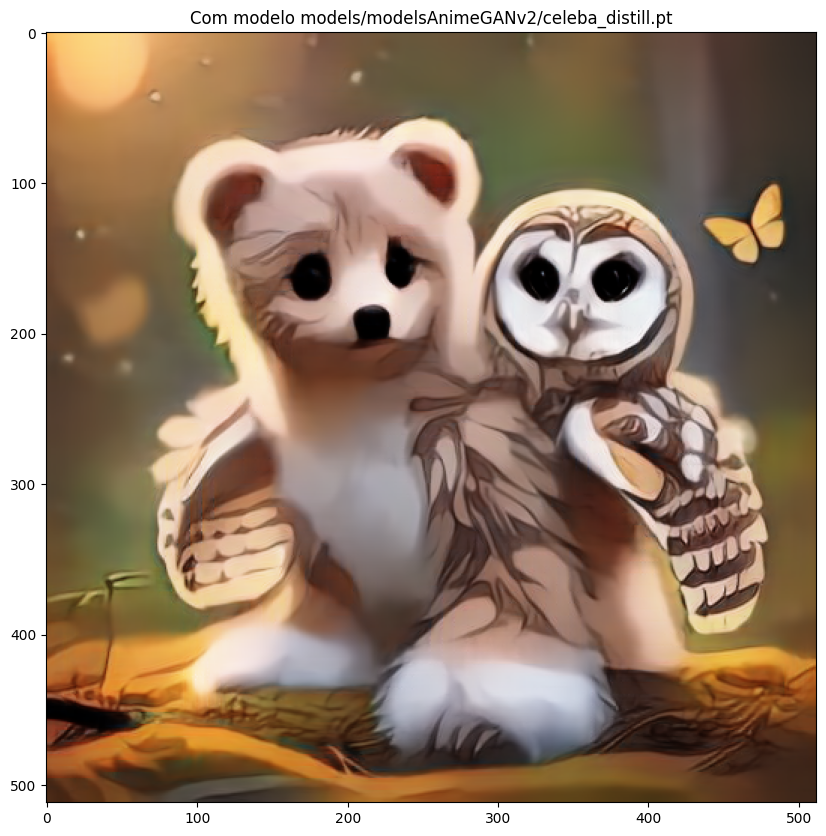

Estilização concluída!
2 Usando modelo: face_paint_512_v1


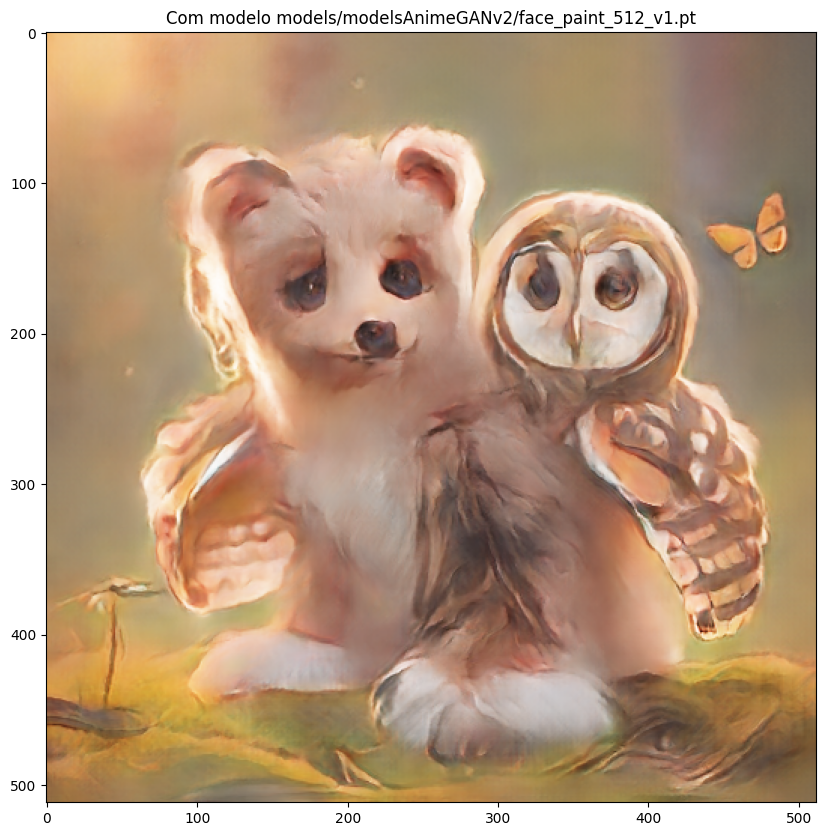

Estilização concluída!
3 Usando modelo: face_paint_512_v2


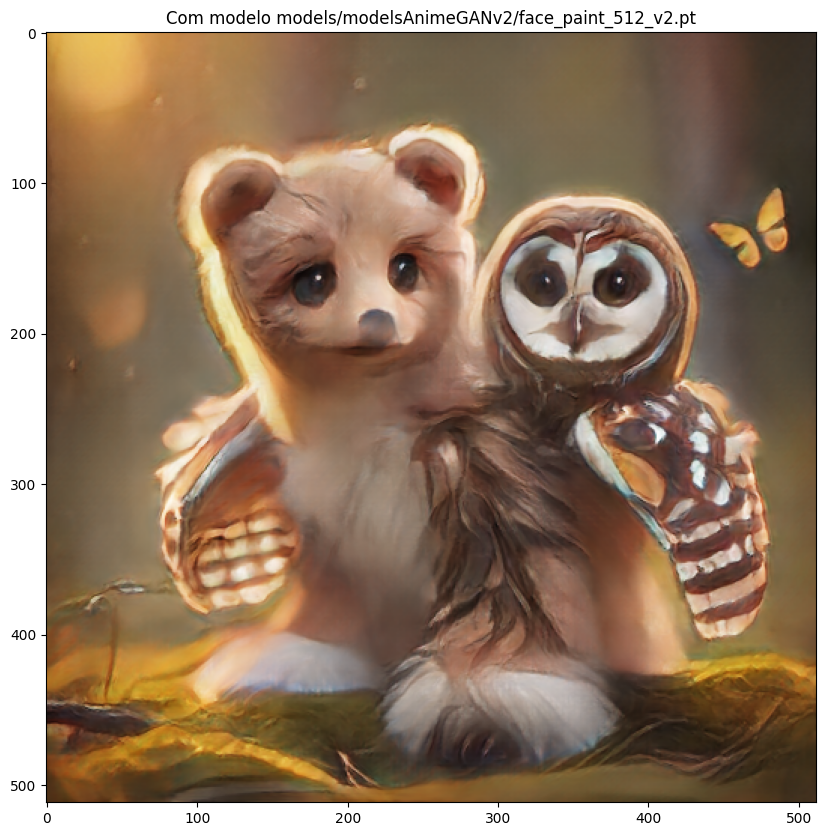

Estilização concluída!
4 Usando modelo: paprika


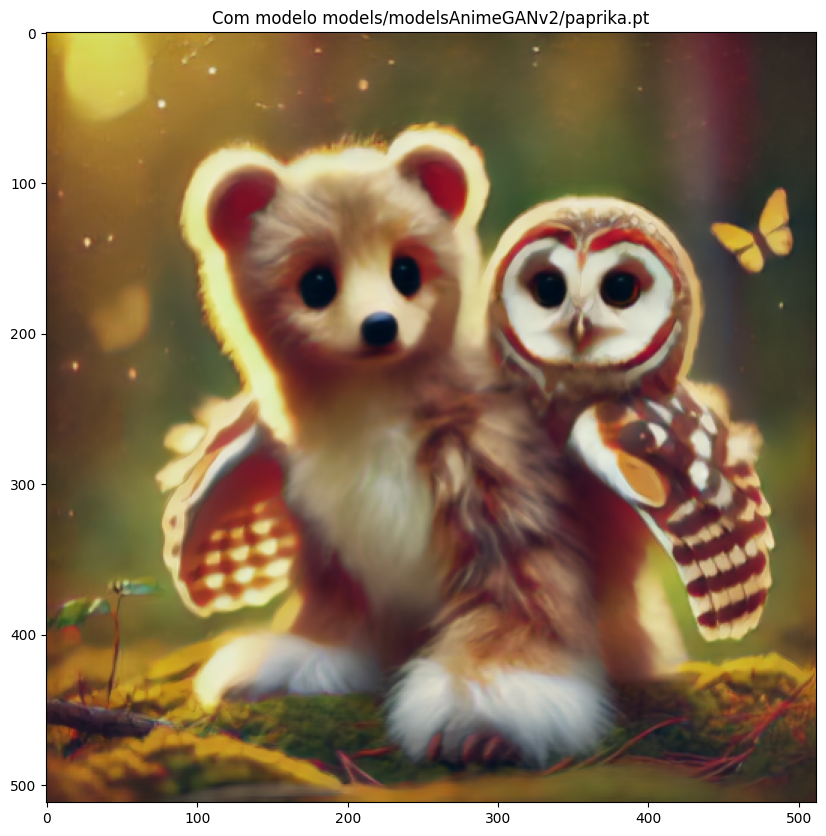

Estilização concluída!


In [20]:
# TESTANDO MODELO ANIME PRETREINADO, ANIMEGANV2
# https://github.com/bryandlee/animegan2-pytorch/tree/main
# https://tachibanayoshino.github.io/AnimeGANv2/

import torch
from torchvision import transforms
from torch import nn
import torch.nn.functional as F

#ARQUITETURA
class ConvNormLReLU(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, pad_mode="reflect", groups=1, bias=False):
        
        pad_layer = {
            "zero":    nn.ZeroPad2d,
            "same":    nn.ReplicationPad2d,
            "reflect": nn.ReflectionPad2d,
        }
        if pad_mode not in pad_layer:
            raise NotImplementedError
            
        super(ConvNormLReLU, self).__init__(
            pad_layer[pad_mode](padding),
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=0, groups=groups, bias=bias),
            nn.GroupNorm(num_groups=1, num_channels=out_ch, affine=True),
            nn.LeakyReLU(0.2, inplace=True)
        )


class InvertedResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, expansion_ratio=2):
        super(InvertedResBlock, self).__init__()

        self.use_res_connect = in_ch == out_ch
        bottleneck = int(round(in_ch*expansion_ratio))
        layers = []
        if expansion_ratio != 1:
            layers.append(ConvNormLReLU(in_ch, bottleneck, kernel_size=1, padding=0))
        
        # dw
        layers.append(ConvNormLReLU(bottleneck, bottleneck, groups=bottleneck, bias=True))
        # pw
        layers.append(nn.Conv2d(bottleneck, out_ch, kernel_size=1, padding=0, bias=False))
        layers.append(nn.GroupNorm(num_groups=1, num_channels=out_ch, affine=True))

        self.layers = nn.Sequential(*layers)
        
    def forward(self, input):
        out = self.layers(input)
        if self.use_res_connect:
            out = input + out
        return out

    
class Generator(nn.Module):
    def __init__(self, ):
        super().__init__()
        
        self.block_a = nn.Sequential(
            ConvNormLReLU(3,  32, kernel_size=7, padding=3),
            ConvNormLReLU(32, 64, stride=2, padding=(0,1,0,1)),
            ConvNormLReLU(64, 64)
        )
        
        self.block_b = nn.Sequential(
            ConvNormLReLU(64,  128, stride=2, padding=(0,1,0,1)),            
            ConvNormLReLU(128, 128)
        )
        
        self.block_c = nn.Sequential(
            ConvNormLReLU(128, 128),
            InvertedResBlock(128, 256, 2),
            InvertedResBlock(256, 256, 2),
            InvertedResBlock(256, 256, 2),
            InvertedResBlock(256, 256, 2),
            ConvNormLReLU(256, 128),
        )    
        
        self.block_d = nn.Sequential(
            ConvNormLReLU(128, 128),
            ConvNormLReLU(128, 128)
        )

        self.block_e = nn.Sequential(
            ConvNormLReLU(128, 64),
            ConvNormLReLU(64,  64),
            ConvNormLReLU(64,  32, kernel_size=7, padding=3)
        )

        self.out_layer = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=1, stride=1, padding=0, bias=False),
            nn.Tanh()
        )
        
    def forward(self, input, align_corners=True):
        out = self.block_a(input)
        half_size = out.size()[-2:]
        out = self.block_b(out)
        out = self.block_c(out)
        
        if align_corners:
            out = F.interpolate(out, half_size, mode="bilinear", align_corners=True)
        else:
            out = F.interpolate(out, scale_factor=2, mode="bilinear", align_corners=False)
        out = self.block_d(out)

        if align_corners:
            out = F.interpolate(out, input.size()[-2:], mode="bilinear", align_corners=True)
        else:
            out = F.interpolate(out, scale_factor=2, mode="bilinear", align_corners=False)
        out = self.block_e(out)

        out = self.out_layer(out)
        return out

caminho = 'models/modelsAnimeGANv2/'
caminhoModelos = [f for f in listdir(caminho) if isfile(join(caminho, f))]

for (item, nomeModelo) in enumerate(caminhoModelos):

    print(str(item+1) + " Usando modelo: " + str(nomeModelo)[:-3])

    # Configurações
    if torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    model_path = f'{caminho+nomeModelo}'  # Altere para o caminho do seu modelo
    input_image_path = "imagens/ursocoruja.jpg"

    # Carregar o modelo
    def load_model(model_path, device):
        model = Generator().to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()  # Modo de avaliação
        return model

    # Pré-processamento da imagem
    def preprocess_image(image_path, size=(512, 512)):
        # Carrega a imagem com OpenCV e converte para RGB
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Redimensiona e converte para tensor
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Ajuste conforme seu modelo
        ])
        
        image = transform(image).unsqueeze(0).to(device)  # Adiciona dimensão de batch
        
        return image

    # Pós-processamento
    def postprocess_image(tensor):
        tensor = tensor.squeeze(0).detach().cpu()  # Remove batch e move para CPU
        tensor = tensor * 0.5 + 0.5  # Desnormalização (ajuste conforme seu modelo)
        image = tensor.numpy().transpose(1, 2, 0)  # (C, H, W) → (H, W, C)
        image = np.clip(image * 255, 0, 255).astype(np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        return image


    model = load_model(model_path, device)
    input_tensor = preprocess_image(input_image_path).to(device)
        
    # Inferência
    with torch.no_grad():
        
        output_tensor = model(input_tensor)
        
    # Salva resultado
    output_image = postprocess_image(output_tensor)
    imshow(f"Com modelo {caminho+nomeModelo}", output_image)
    print("Estilização concluída!")